# ST446 Assignment 2
# Candidate Number: 61396
---

# Import Libraries

In [30]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import time
from statistics import mode
from sklearn import tree

# SparkSession (for Google Colab)
from pyspark.sql import SparkSession

# Spark DataFrame and SQL functions
from pyspark.sql.functions import col, udf,when, isnan,count,isnull,trim, explode, split,array,sum, count
from pyspark.sql.types import IntegerType,StructType, NumericType,DoubleType,StructField, StringType

# Spark MLlib functions
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.feature import (HashingTF, Tokenizer, IDF,
                                StopWordsRemover,StringIndexer,
                                OneHotEncoder,FeatureHasher,
                                 VectorAssembler, StandardScaler)
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.ml import tuning as tune
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
spark.sparkContext.setLogLevel("ERROR")

# Download Data

In [2]:
#Download data
!wget -q https://raw.githubusercontent.com/tfs4/liar_dataset/master/train.tsv
!wget -q https://raw.githubusercontent.com/tfs4/liar_dataset/master/valid.tsv
!wget -q https://raw.githubusercontent.com/tfs4/liar_dataset/master/test.tsv

#Upload to GCS bucket
!gsutil cp train.tsv gs://st446-hw2-sj/
!gsutil cp valid.tsv gs://st446-hw2-sj/
!gsutil cp test.tsv gs://st446-hw2-sj/

#GCS paths
train_path = "gs://st446-hw2-sj/train.tsv"
test_path = "gs://st446-hw2-sj/test.tsv"
val_path = "gs://st446-hw2-sj/valid.tsv"

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://train.tsv [Content-Type=text/tab-separated-values]...
/ [1 files][  2.3 MiB/  2.3 MiB]                                                
Operation completed over 1 objects/2.3 MiB.                                      
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://valid.tsv [Content-Type=text/tab-separated-values]...
/ [1 files][294.5 KiB/294.5 KiB]                                                
Operation completed over 1 objects/294.5 KiB.                                    
Google recommends 

In [3]:
# metadata / schema for the dataset
schema = StructType([
    StructField("id", StringType(), True),
    StructField("label", StringType(), True),
    StructField("statement", StringType(), True),
    StructField("subject", StringType(), True),
    StructField("speaker", StringType(), True),
    StructField("speaker_job", StringType(), True),
    StructField("state", StringType(), True),
    StructField("party", StringType(), True),
    StructField("barely_true_count", DoubleType(), True),
    StructField("false_count", DoubleType(), True),
    StructField("half_true_count", DoubleType(), True),
    StructField("mostly_true_count", DoubleType(), True),
    StructField("pants_on_fire_count", DoubleType(), True),
    StructField("context", StringType(), True)
])

#load in the train, test and val sets from github
liar_train = spark.read.option('sep', '\t').csv(train_path,header=False, schema=schema)
liar_test = spark.read.option('sep', '\t').csv(test_path,header=False, schema=schema)
liar_val = spark.read.option('sep', '\t').csv(val_path,header=False, schema=schema)

#combine all data and print schema
liar_df = liar_train.union(liar_test).union(liar_val)
liar_df.printSchema()
liar_df.show(3)
print('Total rows:', liar_df.count())

root
 |-- id: string (nullable = true)
 |-- label: string (nullable = true)
 |-- statement: string (nullable = true)
 |-- subject: string (nullable = true)
 |-- speaker: string (nullable = true)
 |-- speaker_job: string (nullable = true)
 |-- state: string (nullable = true)
 |-- party: string (nullable = true)
 |-- barely_true_count: double (nullable = true)
 |-- false_count: double (nullable = true)
 |-- half_true_count: double (nullable = true)
 |-- mostly_true_count: double (nullable = true)
 |-- pants_on_fire_count: double (nullable = true)
 |-- context: string (nullable = true)



+----------+-----------+--------------------+--------------------+--------------+--------------------+--------+----------+-----------------+-----------+---------------+-----------------+-------------------+---------------+
|        id|      label|           statement|             subject|       speaker|         speaker_job|   state|     party|barely_true_count|false_count|half_true_count|mostly_true_count|pants_on_fire_count|        context|
+----------+-----------+--------------------+--------------------+--------------+--------------------+--------+----------+-----------------+-----------+---------------+-----------------+-------------------+---------------+
| 2635.json|      false|Says the Annies L...|            abortion|  dwayne-bohac|State representative|   Texas|republican|              0.0|        1.0|            0.0|              0.0|                0.0|       a mailer|
|10540.json|  half-true|When did the decl...|energy,history,jo...|scott-surovell|      State delegate|Virgin

Total rows: 12836


---
# Convert labels to the correct format (binary)

In [4]:
#get distinct labels
liar_df.select(liar_df["label"]).distinct().show()

+-----------+
|      label|
+-----------+
|       true|
|barely-true|
|mostly-true|
|      false|
| pants-fire|
|  half-true|
+-----------+



In [5]:
#label_dict = {'pants-fire':0,'half-true':1,'false':0,'true':1,'mostly-true':1,'barely-true':0}

#converty label categories from 6 to 2 (True/False)
liar_df2 = liar_df.withColumn('label',
                              when(col('label')=='pants-fire',0)
                              .when(col('label')=='half-true',1).when(col('label')=='false',0)
                              .when(col('label')=='true',1).when(col('label')=='mostly-true',1)
                              .when(col('label')=='barely-true',0)
                              .otherwise(None))
liar_df2.show(5)

+----------+-----+--------------------+--------------------+--------------+--------------------+--------+----------+-----------------+-----------+---------------+-----------------+-------------------+-------------------+
|        id|label|           statement|             subject|       speaker|         speaker_job|   state|     party|barely_true_count|false_count|half_true_count|mostly_true_count|pants_on_fire_count|            context|
+----------+-----+--------------------+--------------------+--------------+--------------------+--------+----------+-----------------+-----------+---------------+-----------------+-------------------+-------------------+
| 2635.json|    0|Says the Annies L...|            abortion|  dwayne-bohac|State representative|   Texas|republican|              0.0|        1.0|            0.0|              0.0|                0.0|           a mailer|
|10540.json|    1|When did the decl...|energy,history,jo...|scott-surovell|      State delegate|Virginia|  democrat|

---
# Investigate Missing Values

### Count number of missing values for each column

In [6]:
#for each column, count NaN and nulls 
liar_df2.select([count(when(isnull(colVar)|(col(colVar) == "NaN"), colVar))
                 .alias(colVar)for colVar in liar_df2.columns]).show()

+---+-----+---------+-------+-------+-----------+-----+-----+-----------------+-----------+---------------+-----------------+-------------------+-------+
| id|label|statement|subject|speaker|speaker_job|state|party|barely_true_count|false_count|half_true_count|mostly_true_count|pants_on_fire_count|context|
+---+-----+---------+-------+-------+-----------+-----+-----+-----------------+-----------+---------------+-----------------+-------------------+-------+
|  0|    0|        0|      8|      8|       3580| 2757|    8|                8|          8|              8|                8|                  8|    137|
+---+-----+---------+-------+-------+-----------+-----+-----+-----------------+-----------+---------------+-----------------+-------------------+-------+



### Fill categorical column missing values with "UNKNOWN"

In [7]:
#fill categorical missing values with UNKNOWN
liar_df2 = liar_df2.fillna("UNKNOWN", subset=["speaker_job", "state", "context"])
liar_df2 = liar_df2.replace(float("nan"), None)

#display the columns and remaining missing counts
liar_df2.select([count(when(col(colVar).isNull()|isnan(colVar), colVar)).alias(colVar)
    if isinstance(liar_df2.schema[colVar].dataType, NumericType)
    else count(when(col(colVar).isNull()|(col(colVar) == "NaN"), colVar)).alias(colVar)
    for colVar in liar_df2.columns]).show()

+---+-----+---------+-------+-------+-----------+-----+-----+-----------------+-----------+---------------+-----------------+-------------------+-------+
| id|label|statement|subject|speaker|speaker_job|state|party|barely_true_count|false_count|half_true_count|mostly_true_count|pants_on_fire_count|context|
+---+-----+---------+-------+-------+-----------+-----+-----+-----------------+-----------+---------------+-----------------+-------------------+-------+
|  0|    0|        0|      8|      8|          0|    0|    8|                8|          8|              8|                8|                  8|      0|
+---+-----+---------+-------+-------+-----------+-----+-----+-----------------+-----------+---------------+-----------------+-------------------+-------+



### Drop the remaining missing rows

In [8]:
#drop the remaining 8 missinng rows
liar_df2 = liar_df2.na.drop()

#display the columns and remaining missing counts
liar_df2.select([count(when(col(colVar).isNull()|isnan(colVar), colVar)).alias(colVar)
    if isinstance(liar_df2.schema[colVar].dataType, NumericType)
    else count(when(col(colVar).isNull()|(col(colVar) == "NaN"), colVar)).alias(colVar)
    for colVar in liar_df2.columns]).show()

+---+-----+---------+-------+-------+-----------+-----+-----+-----------------+-----------+---------------+-----------------+-------------------+-------+
| id|label|statement|subject|speaker|speaker_job|state|party|barely_true_count|false_count|half_true_count|mostly_true_count|pants_on_fire_count|context|
+---+-----+---------+-------+-------+-----------+-----+-----+-----------------+-----------+---------------+-----------------+-------------------+-------+
|  0|    0|        0|      0|      0|          0|    0|    0|                0|          0|              0|                0|                  0|      0|
+---+-----+---------+-------+-------+-----------+-----+-----+-----------------+-----------+---------------+-----------------+-------------------+-------+



---
# Exploratory Data Analysis

### Fake vs. True Balance

In [9]:
#show counts of true and false labels
liar_df2.groupBy('label').count().show()

#show true/false counts by political party
liar_df2.groupBy('party','label').count().orderBy('count',ascending=False).show()

+-----+-----+
|label|count|
+-----+-----+
|    1| 7163|
|    0| 5665|
+-----+-----+

+--------------+-----+-----+
|         party|label|count|
+--------------+-----+-----+
|    republican|    1| 2857|
|    republican|    0| 2826|
|      democrat|    1| 2741|
|      democrat|    0| 1406|
|          none|    0| 1102|
|          none|    1| 1083|
|  organization|    0|  137|
|  organization|    1|  128|
|   independent|    1|  127|
|   independent|    0|   54|
|     newsmaker|    1|   42|
|   libertarian|    1|   34|
|    journalist|    1|   31|
|      activist|    1|   30|
|     newsmaker|    0|   24|
|     columnist|    1|   24|
|state-official|    1|   22|
|     columnist|    0|   21|
|talk-show-host|    0|   20|
|    journalist|    0|   18|
+--------------+-----+-----+
only showing top 20 rows



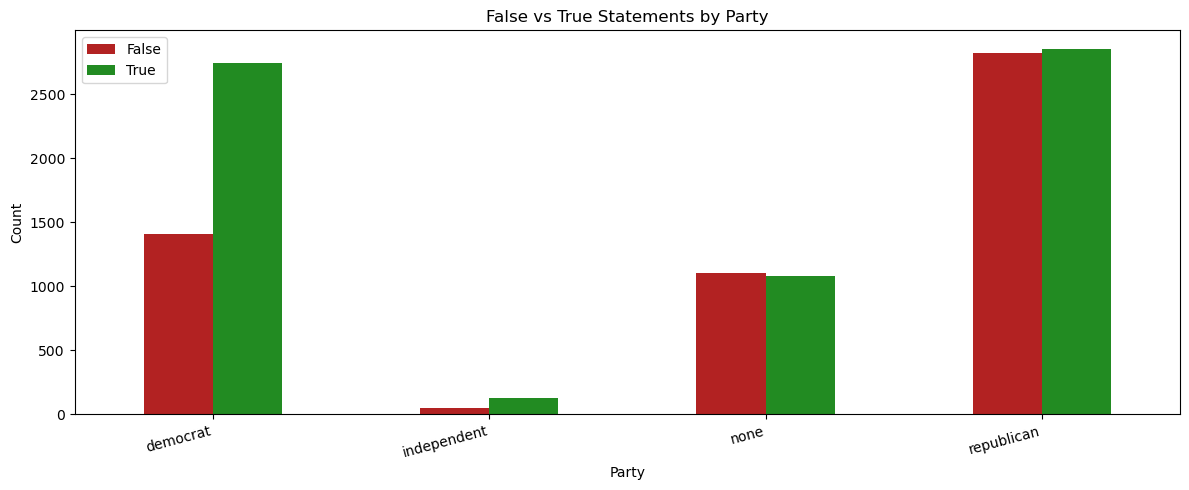

In [10]:
#filter to most popular political parties, count true/false statements and order
#in descending, pivot so values can be plotted below
partyCts = liar_df2.filter(col('party').isin(['democrat', 'republican', 'none', 'independent']))\
.groupBy('party','label').count().orderBy('count',ascending=False)\
.withColumn('label', when(col('label') == 1, 'True').otherwise('False')).toPandas() \
.pivot(index='party', columns='label', values='count')

#bar plot for true and false counts by top political parties
partyCts.plot(kind='bar', figsize=(12, 5), color=['firebrick', 'forestgreen'])
plt.title("False vs True Statements by Party")
plt.xlabel("Party")
plt.ylabel("Count")
plt.xticks(rotation=15, ha="right")
plt.legend(["False", "True"])
plt.tight_layout()
plt.show()

### Label by State

In [11]:
#count the total entries by state
liar_df2.groupBy('state').count().orderBy('count',ascending=False).show(100)

+--------------------+-----+
|               state|count|
+--------------------+-----+
|             UNKNOWN| 2749|
|               Texas| 1263|
|             Florida| 1235|
|           Wisconsin|  904|
|            New York|  831|
|            Illinois|  695|
|                Ohio|  587|
|             Georgia|  546|
|            Virginia|  515|
|        Rhode Island|  455|
|              Oregon|  307|
|          New Jersey|  307|
|       Massachusetts|  253|
|             Arizona|  228|
|          California|  181|
|    Washington, D.C.|  142|
|             Vermont|  118|
|        Pennsylvania|  112|
|       New Hampshire|  107|
|            Arkansas|  103|
|            Kentucky|   99|
|           Tennessee|   88|
|            Maryland|   87|
|            Delaware|   84|
|              Alaska|   81|
|           Minnesota|   75|
|      North Carolina|   72|
|              Nevada|   59|
|             Indiana|   52|
|            Missouri|   49|
|      South Carolina|   39|
|          New

#### Clean "State" column values

In [12]:
#based on the results above there are issues in the state column
#fix trailing white spaces, aliases and misspellings
liar_df2 = liar_df2.withColumn('state',trim(col('state')))
liar_df2 = liar_df2.withColumn('state',
                               when(col('state').isin(['Virginia', 'Virgiia','Virginia director', 
                                                       'Coalition to Stop Gun Violence']),'Virginia')
                               .when(col('state').isin(['Washington D.C.', 'Washington, D.C. ', 
                                                        'District of Columbia',
                                                        'Washington, D.C.']),'Washington, D.C.')
                               .when(col('state').isin(['Rhode Island ', 'Rhode island']),'Rhode Island')
                               .when(col('state').isin(['Qatar', 'United Kingdom', 'China', 
                                                        'Russia','the United States']),'UNKNOWN')
                               .when(col('state')=='Tex','Texas')
                              .when(col('state')=='PA - Pennsylvania','Pennsylvania')
                              .when(col('state')=='Washington state','Washington')
                              .when(col('state')=='Tennesse','Tennessee')
                              .when(col('state')=='ohio ','Ohio')
                              .otherwise(col("state")))

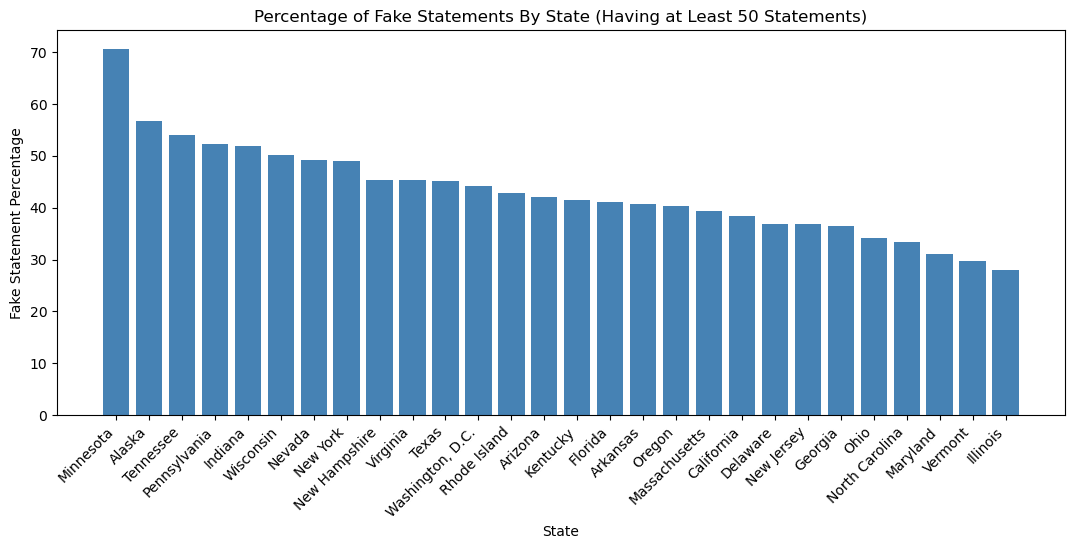

In [13]:
#set up SQL view
liar_df2.createOrReplaceTempView("liar_state")

#calculate the % of fake statements by states with at least 50 entries
state_fake = spark.sql("""
SELECT state, total, fakeCt, ROUND(fakeCt/total*100,2) AS fakePct
FROM (
  SELECT state, COUNT(*) AS total, SUM(CASE WHEN label = 0 THEN 1 ELSE 0 END) AS fakeCt
FROM liar_state
WHERE state !='UNKNOWN'
GROUP BY state
HAVING COUNT (*) >= 50)
ORDER BY fakePct DESC
""").toPandas()

#plot in descending order
plt.figure(figsize=(13, 5))
bars = plt.bar(state_fake["state"], state_fake["fakePct"], color="steelblue")
plt.title("Percentage of Fake Statements By State (Having at Least 50 Statements)")
plt.xlabel("State")
plt.ylabel("Fake Statement Percentage")
plt.xticks(rotation=45, ha="right")
plt.show()

### Credit History (barely true, false, half true, mostly true, pants on fire counts)

<Figure size 1300x500 with 0 Axes>

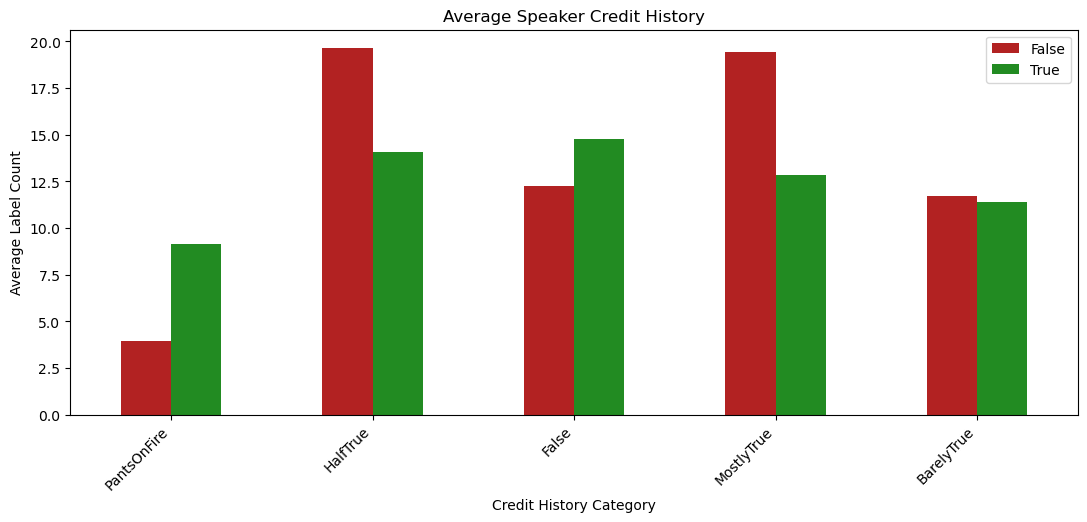

In [14]:
#set up SQL view
liar_df2.createOrReplaceTempView("liar_credit")

#select average counts for each credit history of speaker
creditAvgs = spark.sql("""
SELECT label, AVG(pants_on_fire_count) AS PantsOnFire,
AVG(half_true_count) AS HalfTrue,
AVG(false_count) AS False,
AVG(mostly_true_count)AS MostlyTrue,
AVG(barely_true_count)AS BarelyTrue
FROM liar_credit
GROUP BY label
""").toPandas().set_index('label').T

#plot counts of speaker average credit history based on the label of the 
#statement in that row
plt.figure(figsize=(13, 5))
creditAvgs.plot(kind='bar',figsize=(13, 5),color=['firebrick','forestgreen'])
plt.title("Average Speaker Credit History")
plt.xlabel("Credit History Category")
plt.ylabel("Average Label Count")
plt.legend(["False", "True"])
plt.xticks(rotation=45, ha="right")
plt.show()

### Subject and Context

In [15]:
#get the words in each subject entry and split
#count the instances of common words and order by descending
liar_df2.select(explode(split(col('subject'),',')).alias('MainSubject')) \
.groupBy('MainSubject').count().orderBy('count',ascending=False).show(30)

+--------------------+-----+
|         MainSubject|count|
+--------------------+-----+
|             economy| 1435|
|         health-care| 1432|
|               taxes| 1220|
|      federal-budget|  943|
|           education|  930|
|                jobs|  902|
|        state-budget|  884|
|candidates-biography|  808|
|           elections|  758|
|         immigration|  645|
|      foreign-policy|  604|
|               crime|  556|
|             history|  499|
|              energy|  480|
|         environment|  436|
|        legal-issues|  429|
|                guns|  406|
|            military|  390|
| job-accomplishments|  368|
|           terrorism|  362|
|             workers|  352|
|      transportation|  340|
|message-machine-2012|  323|
|            abortion|  316|
|    criminal-justice|  315|
|      state-finances|  315|
|              states|  288|
|       public-health|  284|
|             deficit|  269|
|             pundits|  264|
+--------------------+-----+
only showing t

In [16]:
#get the words in each context entry and split
#count the instances of common media forms and order by descending
liar_df2.select(explode(split(col('context'),',')).alias('MediaForm')) \
.filter(col('MediaForm')!='UNKNOWN').groupBy('MediaForm').count().orderBy('count',ascending=False).show(30)

+--------------------+-----+
|           MediaForm|count|
+--------------------+-----+
|      a news release|  311|
|        an interview|  286|
|     a press release|  282|
|            a speech|  262|
|             a TV ad|  225|
|             a tweet|  190|
|       a campaign ad|  164|
|     a television ad|  163|
|   a radio interview|  127|
|            a debate|  114|
|   a news conference|  108|
|                N.H.|   98|
|a campaign commer...|   92|
|     a Facebook post|   88|
|  a press conference|   85|
|a television inte...|   83|
|                Fla.|   80|
|           a speech.|   73|
|      a TV interview|   61|
|            a TV ad.|   61|
|    a press release.|   59|
|          a radio ad|   58|
|                Iowa|   54|
|      a chain e-mail|   52|
|       an interview.|   51|
|   a campaign mailer|   49|
|     a news release.|   47|
| an interview on CNN|   46|
|an interview on F...|   46|
|           a debate.|   45|
+--------------------+-----+
only showing t

### Speaker and Speaker Job Title

In [17]:
#count the instances of speaker names
liar_df2.select(explode(split(col('speaker'),',')).alias('Speaker')) \
.groupBy('Speaker').count().orderBy('count',ascending=False).show(30)

+--------------------+-----+
|             Speaker|count|
+--------------------+-----+
|        barack-obama|  614|
|        donald-trump|  344|
|     hillary-clinton|  297|
|         mitt-romney|  215|
|         john-mccain|  189|
|        scott-walker|  184|
|         chain-email|  178|
|          rick-perry|  173|
|         marco-rubio|  153|
|          rick-scott|  150|
|            ted-cruz|  119|
|            bernie-s|  107|
|      chris-christie|  105|
|      facebook-posts|  100|
|       charlie-crist|   90|
|       newt-gingrich|   83|
|        blog-posting|   81|
|            jeb-bush|   79|
|           joe-biden|   76|
|           paul-ryan|   70|
|        john-boehner|   69|
|         john-kasich|   67|
|         sarah-palin|   66|
|    michele-bachmann|   61|
|       rick-santorum|   59|
|           tim-kaine|   54|
|           rand-paul|   52|
|national-republic...|   52|
|         nathan-deal|   52|
|       rudy-giuliani|   47|
+--------------------+-----+
only showing t

In [18]:
#select the speakers, their party and how many real or false labels they have in the dataset
#order by descending total count
liar_df2.select(explode(split(col('speaker'),',')).alias('Speaker'),col('label'),col('party')) \
.groupBy('Speaker','party').agg(sum(when(col('label') == 0, 1).otherwise(0)).alias('fake'),
    sum(when(col('label') == 1, 1).otherwise(0)).alias('real'),count('*').alias('total'))\
    .orderBy('total',ascending=False).show(30)

+--------------------+-----------+----+----+-----+
|             Speaker|      party|fake|real|total|
+--------------------+-----------+----+----+-----+
|        barack-obama|   democrat| 161| 453|  614|
|        donald-trump| republican| 242| 102|  344|
|     hillary-clinton|   democrat|  79| 218|  297|
|         mitt-romney| republican|  89| 126|  215|
|         john-mccain| republican|  80| 109|  189|
|        scott-walker| republican|  84| 100|  184|
|         chain-email|       none| 159|  19|  178|
|          rick-perry| republican|  80|  93|  173|
|         marco-rubio| republican|  64|  89|  153|
|          rick-scott| republican|  63|  87|  150|
|            ted-cruz| republican|  78|  41|  119|
|            bernie-s|independent|  30|  77|  107|
|      chris-christie| republican|  36|  69|  105|
|      facebook-posts|       none|  68|  32|  100|
|       charlie-crist|   democrat|  32|  58|   90|
|       newt-gingrich| republican|  45|  38|   83|
|        blog-posting|       no

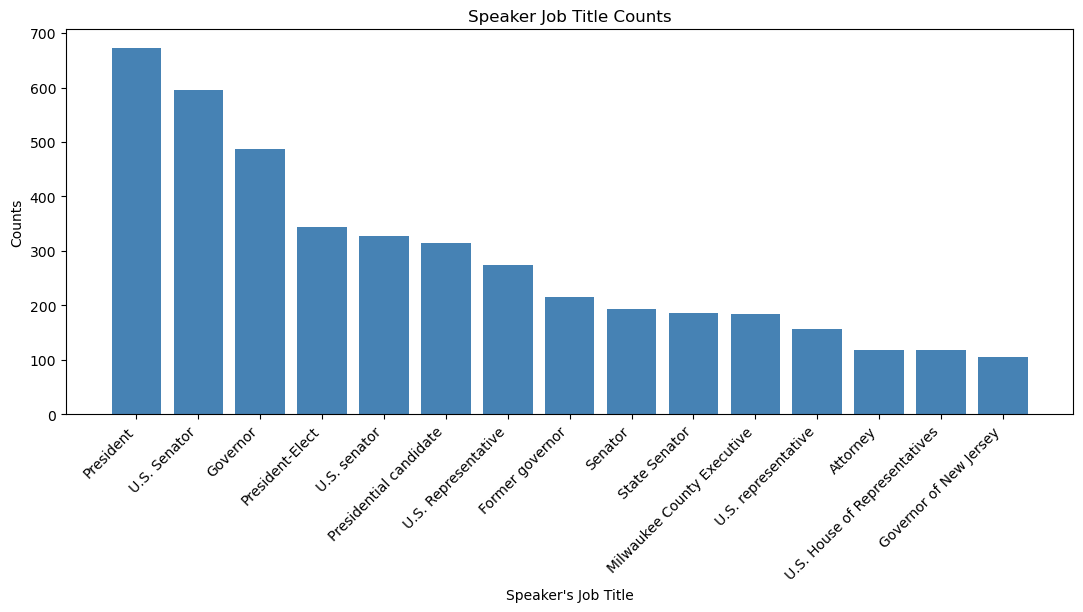

In [19]:
#count number of entries for each speaker job title
#order by descending count and limit to 15 for the plot
speakJob = liar_df2.select(explode(split(col('speaker_job'),',')).alias('SpeakerJobTitle')) \
.filter(col('SpeakerJobTitle')!='UNKNOWN').groupBy('SpeakerJobTitle').count()\
.orderBy('count',ascending=False).limit(15).toPandas()

#plot in descending order by count
plt.figure(figsize=(13, 5))
bars = plt.bar(speakJob["SpeakerJobTitle"], speakJob["count"], color="steelblue")
plt.title("Speaker Job Title Counts")
plt.xlabel("Speaker's Job Title")
plt.ylabel("Counts")
plt.xticks(rotation=45, ha="right")
plt.show()

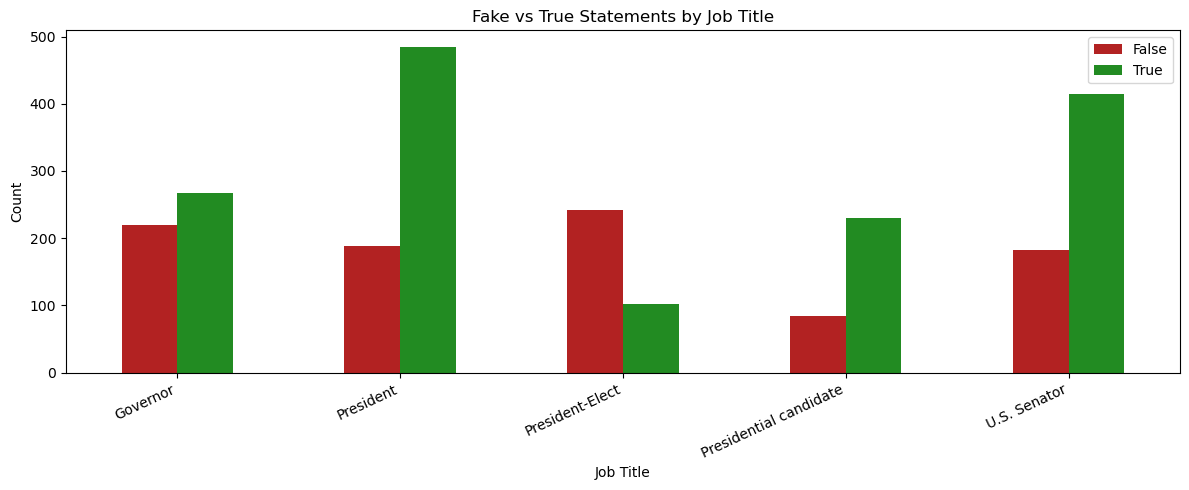

In [20]:
#select the top or important job titles
#separate counts for true and false labels
#pivot the table for plotting purposes
jobLabels = liar_df2.select(explode(split(col('speaker_job'),',')).alias('SpeakerJobTitle'),col('label')) \
.filter(col('SpeakerJobTitle').isin(['President', 'U.S. Senator', 
                                     'Governor', 'President-Elect',
                                     'Presidential candidate'])) \
.groupBy('SpeakerJobTitle','label').count().withColumn('label', when(col('label') == 1, 'True').otherwise('False')) \
.orderBy('SpeakerJobTitle', 'label').toPandas().pivot(index='SpeakerJobTitle',columns='label',values='count')

#side-by-side barplot for true/false counts by job title
jobLabels.plot(kind='bar', figsize=(12, 5), color=['firebrick', 'forestgreen'])
plt.title("Fake vs True Statements by Job Title")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.legend(["False", "True"])
plt.tight_layout()
plt.show()

### Cardinality of categorical variables

In [21]:
#print the number of unique values in each categorical vairable to investigate cardinality
print('Distinct Values for Each Categorical Variable\n')
for x in ['party', 'state', 'subject', 'context', 'speaker', 'speaker_job']:
    print(x,":", liar_df2.select(x).distinct().count())

Distinct Values for Each Categorical Variable

party : 24
state : 60
subject : 4547
context : 5157
speaker : 3317
speaker_job : 1362


---
# Data Splitting

In [22]:
#use a 70%/30% training and testing split in the pre-processed data
liar_train_set, liar_test_set = liar_df2.randomSplit([0.7, 0.3], seed=125)

print("Train shape:",liar_train_set.count())
print("Test shape:",liar_test_set.count())

Train shape: 9046
Test shape: 3782


---
# Pipeline Definition

In [23]:
#tokenize the statement column for words
tokenizer = Tokenizer(inputCol='statement', outputCol='words')

#filters out stop words from statement words(like "the" or "a")
remover = StopWordsRemover(inputCol=tokenizer.getOutputCol(), outputCol='cleaned')

#maps a sequence of terms to their term frequencies using the hashing trick
#filtered statement tokens mapped to numeric feature vector using 300 features
hashingTF = HashingTF(inputCol=remover.getOutputCol(), outputCol='rawFeatures',numFeatures=300)

#TF-IDF:reflect the importance of a term to a document in the corpus
#term frequencies are calculated based on the mapped indices, 
idf = IDF(inputCol=hashingTF.getOutputCol(), outputCol='TFIDF_Features')

#low cardinality - "state" and "party"
#StringIndexer - encode to a numeric index
#OneHotEncoder - maps indices to a column of binary vectors
stateIndexer = StringIndexer(inputCol='state', outputCol='stateIndx',handleInvalid='keep')
stateEncoder = OneHotEncoder(inputCol='stateIndx', outputCol='stateVec')

partyIndexer = StringIndexer(inputCol='party', outputCol='partyIndx',handleInvalid='keep')
partyEncoder = OneHotEncoder(inputCol='partyIndx', outputCol='partyVec')

#high cardinality - "subject", "speaker", "speaker_job","context"
#projects set of categorical features into a feature vector of dim 128
#OneHotEncoder isn't useful for these cols due to high cardinality
#had to limit dimension size due to memory crashin issues
hasher = FeatureHasher(inputCols=['subject', 'speaker', 'speaker_job','context'],
                       outputCol='hashFeatures',numFeatures=128)

#feature transformer to merge the numerical columns into a vector column
numAssembler = VectorAssembler(
    inputCols=['barely_true_count', 'false_count', 'half_true_count',
               'mostly_true_count','pants_on_fire_count'],
    outputCol='numRawFeatures')

#Standardizes features by removing the mean and scaling to 
#unit variance using column summary statistics on the samples in the training set
scaler = StandardScaler(inputCol='numRawFeatures', 
                        outputCol='numRawScaled', 
                        withStd=True, withMean=False)

#feature transformer that combines the previously transformed columns to a single vector
assembler = VectorAssembler(inputCols=['TFIDF_Features','hashFeatures','stateVec',
                                       'partyVec','numRawScaled'], outputCol='raw_features')

---
# Baseline Model - Decision Tree

In [24]:
#use basic decision tree model on the assembler features with max depth of 5
dt = DecisionTreeClassifier(featuresCol="raw_features",labelCol="label",maxDepth=5)

#instantiate pipeline using all definitions from before
pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf,
                            stateIndexer,stateEncoder,partyIndexer,
                            partyEncoder,hasher,numAssembler,scaler,
                            assembler, dt])

#fit the basic model on the training split and get predicitons on test set 
pipelineModel = pipeline.fit(liar_train_set)
predictionsBasic = pipelineModel.transform(liar_test_set)

In [25]:
#summarizing the pipeline stages that will be used throughout
pipelineModel.stages

[Tokenizer_3612f3daef35,
 StopWordsRemover_4ebf0233954c,
 HashingTF_a063e4ee0b8a,
 IDFModel: uid=IDF_8e7a981e43fd, numDocs=9046, numFeatures=300,
 StringIndexerModel: uid=StringIndexer_eca3a3c414cb, handleInvalid=keep,
 OneHotEncoderModel: uid=OneHotEncoder_6f2b79ba1c60, dropLast=true, handleInvalid=error,
 StringIndexerModel: uid=StringIndexer_185ba169550f, handleInvalid=keep,
 OneHotEncoderModel: uid=OneHotEncoder_f238ed7e7ed9, dropLast=true, handleInvalid=error,
 FeatureHasher_bb7f621b90e6,
 VectorAssembler_52468156bd9e,
 StandardScalerModel: uid=StandardScaler_d3e14d893626, numFeatures=5, withMean=false, withStd=true,
 VectorAssembler_4d4e212378ae,
 DecisionTreeClassificationModel: uid=DecisionTreeClassifier_452f59f6d7d3, depth=5, numNodes=49, numClasses=2, numFeatures=511]

In [26]:
#function for evaluation metrics (includes AUC-ROC)
def evaluate_model(testPred, modelName):
    print(f"Evaluation For {modelName}")
    multiClassEval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
    binaryClassEval = BinaryClassificationEvaluator(labelCol="label")
    
    acc = multiClassEval.setMetricName('accuracy').evaluate(testPred)
    print(f"Accuracy: {acc:.5f}")
    
    roc = binaryClassEval.setMetricName('areaUnderROC').evaluate(testPred)
    print(f"AUC-ROC: {roc:.5f}")
    
    f1 = multiClassEval.setMetricName('f1').evaluate(testPred)
    print(f"F1: {f1:.5f}")
    
    prec = multiClassEval.setMetricName('weightedPrecision').evaluate(testPred)
    print(f"Precision: {prec:.5f}")
    
    rec = multiClassEval.setMetricName('weightedRecall').evaluate(testPred)
    print(f"Recall: {rec:.5f}")

In [27]:
#evaluation metrics
predictionsBasic.cache()
evaluate_model(predictionsBasic,'Baseline Model - Decision Tree')

26/04/04 11:43:17 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Evaluation For Baseline Model - Decision Tree


Accuracy: 0.69619
AUC-ROC: 0.62116
F1: 0.68033
Precision: 0.70469
Recall: 0.69619


---
# Sophisticated Models

### Sophisticated  Model - Tuning Basic Decision Tree

In [28]:
#starting tree for tuing
dt = DecisionTreeClassifier(featuresCol='raw_features',labelCol='label')

#reset the pipeline (same as above)
pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf,
                            stateIndexer,stateEncoder,partyIndexer,
                            partyEncoder,hasher,numAssembler,scaler,
                            assembler,dt])

#set the evaluator for cross validation - accuracy
evaluator_cv = MulticlassClassificationEvaluator(labelCol='label', metricName='accuracy')

#set the parameters to gird search over
#max depth, min instances per node and impurity
grid = tune.ParamGridBuilder()\
    .addGrid(dt.maxDepth, [10,15,20])\
    .addGrid(dt.minInstancesPerNode, [5,10,15])\
    .addGrid(dt.impurity, ["gini","entropy"])\
    .build()

#3-fold cross validation using grid from above
cv = tune.CrossValidator(estimator=pipeline, estimatorParamMaps=grid,
                         evaluator=evaluator_cv, numFolds=3,seed=125)

#fit the models on the training set and extract the best one
cv_model_dt = cv.fit(liar_train_set)
best_dt_model = cv_model_dt.bestModel
pred_grid = best_dt_model.transform(liar_test_set)

#get the info for the best tuned model
tunedDt = cv_model_dt.bestModel.stages[-1]
print(f"Best maxDepth: {tunedDt.getMaxDepth()}")
print(f"Best minInstancesPerNode: {tunedDt.getMinInstancesPerNode()}")
print(f"Best impurity: {tunedDt.getImpurity()}")

#evaluate best model
evaluate_model(pred_grid, 'Tuned Tree')

Best maxDepth: 10
Best minInstancesPerNode: 15
Best impurity: gini
Evaluation For Tuned Tree
Accuracy: 0.70968
AUC-ROC: 0.73566
F1: 0.70454
Precision: 0.70846
Recall: 0.70968


### Sophisticated  Model - Bagging

In [31]:
#baseline weak learner (deep so high-variance) for bagging start
dtBag = DecisionTreeClassifier(featuresCol='raw_features',labelCol='label',maxDepth=30)

#pipeline instantiation (same as before)
pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf,
                            stateIndexer,stateEncoder,partyIndexer,
                            partyEncoder,hasher,numAssembler,scaler,
                            assembler])

#max trees to bag 
max_iter= 30

#feature pipeline on training data only to transform for bagging
pipeline_model2 = pipeline.fit(liar_train_set)

#apply transformations on training and testing sets - convert to feature vectors
#cache to avoid doing this each bagging instance
liar_train_features = pipeline_model2.transform(liar_train_set).select('raw_features', 'label').cache()
liar_test_features = pipeline_model2.transform(liar_test_set).select('raw_features', 'label').cache()

#function to preform bagging
def bagging(train_df, tree, max_iter=15):
    models = []
    for i in range(max_iter):
        #get a bootstrap sample with replacement on all data
        bag = train_df.sample(withReplacement=True, fraction=1.0)
        
        #add the model # to prediction results
        tree.setPredictionCol(f"prediction_{i}")
        tree.setProbabilityCol(f"probability_{i}")
        tree.setRawPredictionCol(f"rawPrediction_{i}")
        
        #fit the passed in model on the sample of data and append results
        models.append(tree.fit(bag))
    return models

#evaluator for assesing the bagged trees
evaluator = MulticlassClassificationEvaluator(labelCol='label',metricName='f1',)

#checking the performance of each model (accuracy)
def test_individual_models(test_feat, models):
    for i in range(len(models)):
        #predict model i on test set
        prediction = models[i].transform(test_feat)
        evaluator.setPredictionCol(f"prediction_{i}")
        
        #get accuracy
        acc = evaluator.evaluate(prediction)
        print(f"Accuracy model {i}: {acc}")


#perform the bagging ensemble/train using the weak learner
models = bagging(liar_train_features, dtBag,max_iter)

#get accuracy for each of the 30 models
test_individual_models(liar_test_features, models)

#put all 30 models into single pipeline to transform
pipeline_models = PipelineModel(stages=models)
prediction = pipeline_models.transform(liar_test_features)

#arrange predictions into array, get majority votes for the 30 models
ensemble = prediction.select(array([f"prediction_{i}" for i in range(max_iter)]).alias("preds"),
                             array([f"probability_{i}" for i in range(max_iter)]).alias("probs"),
                             "label",)

#aggregate for majority vote, put into prediction column and show sample
mode_udf = udf(mode, DoubleType())
prediction = ensemble.withColumn('prediction', mode_udf('preds'))
probabilitiesCombined = []
classOneProb = 0
for i in range(max_iter):
    probabilitiesCombined.append(vector_to_array(col('probs')[i]))
for i in probabilitiesCombined:
    classOneProb = classOneProb + i[1]
probsAveraged = classOneProb/ max_iter
prediction = prediction.withColumn("avgProb", probsAveraged)
prediction.show(5)

Accuracy model 0: 0.6602950035467808
Accuracy model 1: 0.6669171288059812
Accuracy model 2: 0.6508102861543892
Accuracy model 3: 0.6695030344974756
Accuracy model 4: 0.6640215697086069
Accuracy model 5: 0.6643749956279327
Accuracy model 6: 0.6642640738473682
Accuracy model 7: 0.6617205272392853
Accuracy model 8: 0.675245331292188
Accuracy model 9: 0.6731545792645438
Accuracy model 10: 0.6630208285827192
Accuracy model 11: 0.6627831877430379
Accuracy model 12: 0.6670341624931667
Accuracy model 13: 0.6652764439852024
Accuracy model 14: 0.6656418719818047
Accuracy model 15: 0.6766341708728598
Accuracy model 16: 0.6682784273107986
Accuracy model 17: 0.6755602994701697
Accuracy model 18: 0.6629094088660512
Accuracy model 19: 0.6613028484664127
Accuracy model 20: 0.6588078992994029
Accuracy model 21: 0.6678348236399083
Accuracy model 22: 0.6803159996823345
Accuracy model 23: 0.6748396633512377
Accuracy model 24: 0.656920131164516
Accuracy model 25: 0.6609608384351183
Accuracy model 26: 0.656

26/04/04 11:50:10 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB


+--------------------+--------------------+-----+----------+-------------------+
|               preds|               probs|label|prediction|            avgProb|
+--------------------+--------------------+-----+----------+-------------------+
|[0.0, 1.0, 0.0, 0...|[[0.9659367396593...|    0|       0.0|0.42578611558086765|
|[0.0, 1.0, 0.0, 1...|[[1.0,0.0], [0.0,...|    0|       0.0| 0.3641362844600853|
|[0.0, 1.0, 1.0, 0...|[[1.0,0.0], [0.0,...|    0|       0.0| 0.4991539763113367|
|[1.0, 1.0, 1.0, 1...|[[0.0,1.0], [0.0,...|    1|       1.0|                1.0|
|[0.0, 1.0, 1.0, 1...|[[1.0,0.0], [0.0,...|    0|       0.0| 0.5319321031891171|
+--------------------+--------------------+-----+----------+-------------------+
only showing top 5 rows



In [33]:
#evaluation metrics for bagging (no AUC-ROC)
def evaluate_model_bag(testPred, modelName):
    print(f"Evaluation For {modelName}")
    multiClassEval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

    acc = multiClassEval.setMetricName('accuracy').evaluate(testPred)
    print(f"Accuracy: {acc:.5f}")

    binEval = BinaryClassificationEvaluator(labelCol="label",
                                            rawPredictionCol="avgProb",metricName="areaUnderROC")
    auc = binEval.evaluate(testPred)
    print(f"AUC-ROC: {auc:.5f}")
    
    f1 = multiClassEval.setMetricName('f1').evaluate(testPred)
    print(f"F1: {f1:.5f}")
    
    prec = multiClassEval.setMetricName('weightedPrecision').evaluate(testPred)
    print(f"Precision: {prec:.5f}")
    
    rec = multiClassEval.setMetricName('weightedRecall').evaluate(testPred)
    print(f"Recall: {rec:.5f}")
    
#check performance of final bagging model
evaluator.setPredictionCol('prediction')
evaluate_model_bag(prediction,'Sophisticated  Model - Bagging')

Evaluation For Sophisticated  Model - Bagging


26/04/04 11:50:23 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


Accuracy: 0.70783


26/04/04 11:50:25 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


AUC-ROC: 0.78721


...

F1: 0.70361


26/04/04 11:50:27 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


Precision: 0.70606


26/04/04 11:50:28 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


Recall: 0.70783


# Comparison of Baseline vs. Sophisticated Model

### Variable Data Size

In [34]:
variableSizeRes = []
max_iter=30

#loop through testing each model type on 25%,50%,75% and 100% of full dataset
for x in [.25,.5,.75,1.0]:
    
    #get the new data according to size % in the iteration, count the num rows
    smallerSamp = liar_train_set.sample(fraction=x, seed=125)
    newRows = smallerSamp.count()
    
    #run the basic decision tree on the sample of data (same method as done previously)
    dtBase = DecisionTreeClassifier(featuresCol='raw_features',labelCol='label',maxDepth=5)
    pipelineBase = Pipeline(stages=[tokenizer, remover, hashingTF, idf,
                            stateIndexer,stateEncoder,partyIndexer,
                            partyEncoder,hasher,numAssembler,scaler,
                            assembler, dtBase])
    
    #measure training time for basic model
    #Spark doesn't immediately execute transformation when called 
    #.count() to force the execution to happen and time measured to be meaningful
    startTimeBase = time.time()
    modelBase = pipelineBase.fit(smallerSamp)
    modelBaseTransf = modelBase.transform(liar_test_set).cache()
    modelBaseTransf.count()
    endTimeBase = time.time()
    totalTimeBase = endTimeBase-startTimeBase
    baseAcc = MulticlassClassificationEvaluator(labelCol='label',metricName='f1').evaluate(modelBase.transform(liar_test_set))

    
    #run the tuned decision tree on the sample of data (same method as done previously)
    #measure training time for tuning
    startTimeTune = time.time()
    crossValModel = cv.fit(smallerSamp)
    modelTunedTransf = crossValModel.transform(liar_test_set).cache()
    modelTunedTransf.count()
    endTimeTune = time.time()
    totalTimeTuned = endTimeTune - startTimeTune
    tunedAcc = MulticlassClassificationEvaluator(labelCol='label', metricName='f1') \
              .evaluate(crossValModel.bestModel.transform(liar_test_set))

    #run the bagging on the sample of data (same method as done previously)
    dtBag = DecisionTreeClassifier(featuresCol='raw_features', labelCol='label', maxDepth=30)
    trainingFeatures = pipeline_model2.transform(smallerSamp).select('raw_features', 'label').cache()
    trainingFeatures.count()
    
    #measure training time for bagging
    startTimeBag = time.time()
    modelBag = bagging(trainingFeatures, dtBag, max_iter)
    endTimeBag = time.time()
    totalTimeBag = endTimeBag-startTimeBag

    pipelineBag = PipelineModel(stages=modelBag)
    predBag = pipelineBag.transform(liar_test_features)
    ensemble = predBag.select(array([f"prediction_{i}" for i in range(max_iter)]).alias("preds"),"label",)
    predictionFinalBag = ensemble.withColumn("prediction", mode_udf("preds"))
    evaluator.setPredictionCol('prediction')
    bagAcc = evaluator.evaluate(predictionFinalBag)

    #append results to data frame for accuracy and training time
    variableSizeRes.append((newRows, totalTimeBase, baseAcc,totalTimeTuned, tunedAcc, totalTimeBag, bagAcc))
    print(f"Row Count: {newRows}")
    print(f"Base Tree Results: {baseAcc:.5f} - {totalTimeBase:.3f}s")
    print(f"Tuned Tree Results: {tunedAcc:.5f} - {totalTimeTuned:.3f}s")
    print(f"Bagging Results: {bagAcc:.5f} - {totalTimeBag:.3f}s\n")


26/04/04 11:53:49 WARN DAGScheduler: Broadcasting large task binary with size 1643.9 KiB


Row Count: 2308
Base Tree Results: 0.69213 - 3.812s
Tuned Tree Results: 0.70555 - 112.173s
Bagging Results: 0.69673 - 55.122s



26/04/04 11:57:02 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB


Row Count: 4561
Base Tree Results: 0.66930 - 4.173s
Tuned Tree Results: 0.70517 - 124.592s
Bagging Results: 0.70026 - 60.427s



26/04/04 12:00:37 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB


Row Count: 6853
Base Tree Results: 0.68484 - 4.159s
Tuned Tree Results: 0.71533 - 139.071s
Bagging Results: 0.70106 - 68.912s



26/04/04 12:04:34 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


Row Count: 9046
Base Tree Results: 0.68033 - 4.451s
Tuned Tree Results: 0.70454 - 152.579s
Bagging Results: 0.70162 - 74.960s



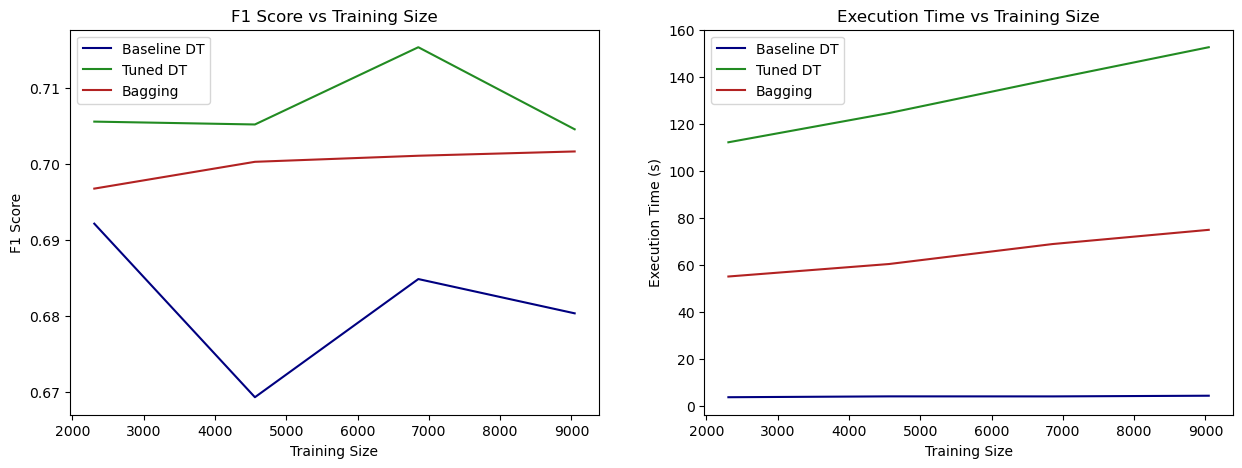

In [ ]:
#put accuracy and training times into a labeled data frame
varSizeResultsDf = pd.DataFrame(variableSizeRes, columns=['Rows', 'Base Tree Time', 
                                                          'Base Tree Acc', 'Tuned Tree Time', 
                                                          'Tuned Tree Acc','Bagging Time', 
                                                          'Bagging Acc'])

#plot for accuracy vs training data size
plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
plt.plot(varSizeResultsDf['Rows'], varSizeResultsDf['Base Tree Acc'], label="Baseline DT",color="navy")
plt.plot(varSizeResultsDf['Rows'], varSizeResultsDf['Tuned Tree Acc'],label="Tuned DT",color="forestgreen")
plt.plot(varSizeResultsDf['Rows'], varSizeResultsDf['Bagging Acc'],label="Bagging",color="firebrick")
plt.title("F1 Score vs Training Size")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.legend()

#plot for training time vs training data size
plt.subplot(1,2,2)
plt.plot(varSizeResultsDf['Rows'], varSizeResultsDf['Base Tree Time'], label="Baseline DT", color="navy")
plt.plot(varSizeResultsDf['Rows'], varSizeResultsDf['Tuned Tree Time'], label="Tuned DT",color="forestgreen")
plt.plot(varSizeResultsDf['Rows'], varSizeResultsDf['Bagging Time'], label="Bagging",color="firebrick")
plt.title("Execution Time vs Training Size")
plt.xlabel("Training Size")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.show()